In [ ]:
# --- project bootstrap ---
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.chdir(ROOT)
# -------------------------


# Test coherent_term in run_markov_circuit

This notebook runs a small DW Markov circuit with and without a coherent term, using the exact DW Hamiltonian for the top layer.

In [1]:
import os
import multiprocessing as mp

cpu_cap = 20
cpu_count = mp.cpu_count()
cpu_use = min(cpu_cap, cpu_count)
os.environ["MY_CPU_COUNT"] = str(cpu_use)
os.environ["OMP_NUM_THREADS"] = str(cpu_use)
os.environ["OPENBLAS_NUM_THREADS"] = str(cpu_use)
os.environ["MKL_NUM_THREADS"] = str(cpu_use)
os.environ["NUMEXPR_MAX_THREADS"] = str(cpu_use)
try:

    os.sched_setaffinity(0, set(range(112-cpu_use, 112)))
except Exception as exc:
    print(f"CPU affinity not set: {exc}")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from fgtn.classA_U1FGTN import classA_U1FGTN

In [10]:
# Small system + small samples for a quick test
Nx, Ny = 10, 10
alpha_1, alpha_2 = 30, 1
cycles = 20
samples = 1
p_meas = 1.0

model = classA_U1FGTN(Nx, Ny, nshell=None, DW=True, alpha_1=alpha_1, alpha_2=alpha_2)


DWs at x=(3, 7)
------------------------- classA_U1FGTN Initialized -------------------------


In [11]:
# Exact domain-wall Hamiltonian on the top layer
H_dw = model._domain_wall_hamiltonian(periodic=True)
print('H_dw shape:', H_dw.shape)


H_dw shape: (200, 200)


In [12]:
# Run without coherent term
res_none = model.run_markov_circuit(
    G_history=False,
    cycles=cycles,
    samples=samples,
    p_meas=p_meas,
    save=False,
    progress=True,
    top_triv_back_forth=True,
    sequence="dw_symmetric_random"
)
G_none = res_none['G_final_avg']

# Run with coherent term
res_coh = model.run_markov_circuit(
    G_history=False,
    cycles=cycles,
    samples=samples,
    p_meas=p_meas,
    save=False,
    progress=True,
    coherent_term=H_dw,
    top_triv_back_forth=True,
    sequence="dw_symmetric_random"
)
G_coh = res_coh['G_final_avg']

print('Done.')


Sample 1 | Markov RAC (DW boundary sweep):   0%|          | 0/2000 [00:00<?, ?site/s]

Sample 1 | Markov RAC (DW boundary sweep):   0%|          | 0/2000 [00:00<?, ?site/s]

Done.


In [13]:
# Simple diagnostics: compare traces and Frobenius norm difference
def fro_norm(A):
    return np.linalg.norm(A, ord='fro')

print('Trace G_none:', np.trace(G_none))
print('Trace G_coh :', np.trace(G_coh))
print('||G_coh - G_none||_F:', fro_norm(G_coh - G_none))


Trace G_none: (2.000000000000367+0j)
Trace G_coh : (1.999999999939316-4.389866833758027e-16j)
||G_coh - G_none||_F: 13.531457654404672


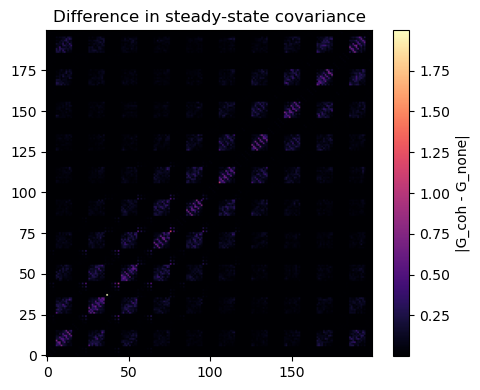

In [14]:
# Optional: visualize absolute difference heatmap
plt.figure(figsize=(5, 4))
plt.imshow(np.abs(G_coh - G_none), origin='lower', cmap='magma')
plt.colorbar(label='|G_coh - G_none|')
plt.title('Difference in steady-state covariance')
plt.tight_layout()
plt.show()


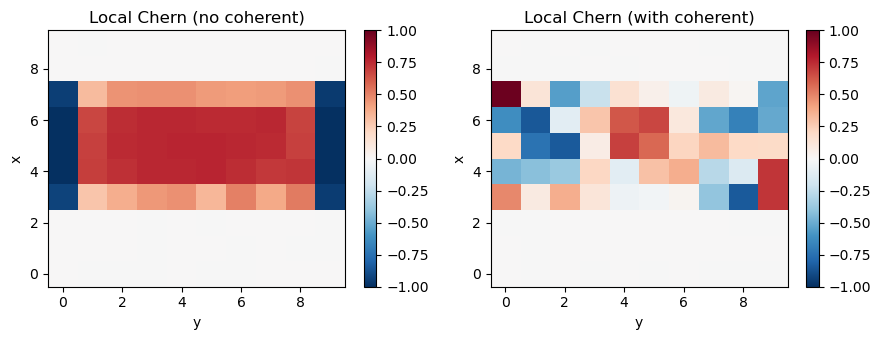

In [15]:
# Local Chern marker (tanh) for both steady states
ch_none = model.local_chern_marker_flat(G_none)
ch_coh = model.local_chern_marker_flat(G_coh)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
im0 = axes[0].imshow(ch_none, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Local Chern (no coherent)')
axes[0].set_xlabel('y')
axes[0].set_ylabel('x')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ch_coh, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('Local Chern (with coherent)')
axes[1].set_xlabel('y')
axes[1].set_ylabel('x')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


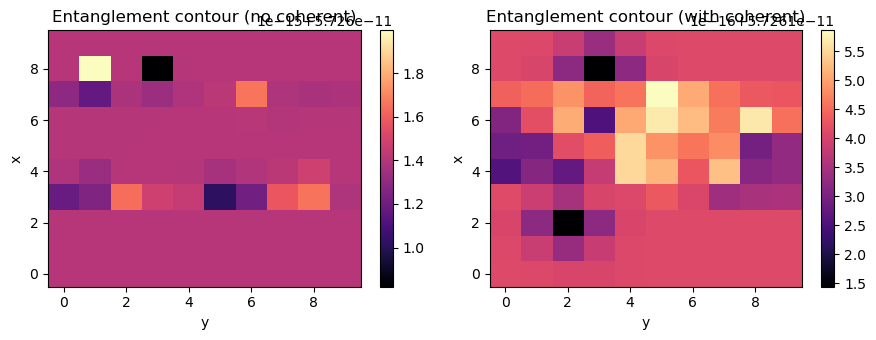

In [16]:
# Entanglement contour heatmaps on the top layer for both steady states
def entanglement_contour(G_top, Nx, Ny):
    I = np.eye(G_top.shape[0], dtype=np.complex128)
    G2 = 0.5 * (I + G_top)
    evals, vecs = np.linalg.eigh(G2)
    evals = np.clip(np.real_if_close(evals), 1e-12, 1 - 1e-12)
    f_eigs = -(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))
    diagF = np.einsum("ik,k,ik->i", vecs, f_eigs, vecs.conj(), optimize=True).real
    diagF = diagF.reshape(2, Nx, Ny, order="F")
    return diagF.sum(axis=0)

s_none = entanglement_contour(G_none, Nx, Ny)
s_coh = entanglement_contour(G_coh, Nx, Ny)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
im0 = axes[0].imshow(s_none, origin='lower', cmap='magma', aspect='auto')
axes[0].set_title('Entanglement contour (no coherent)')
axes[0].set_xlabel('y')
axes[0].set_ylabel('x')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(s_coh, origin='lower', cmap='magma', aspect='auto')
axes[1].set_title('Entanglement contour (with coherent)')
axes[1].set_xlabel('y')
axes[1].set_ylabel('x')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()
